# Hari 26 — Interpretasi Final & Menyiapkan Fungsi Prediksi

**Model final:** Linear Regression v2 (`model_final_v2.pkl`)

Dua masalah yang perlu diselesaikan hari ini sebelum bisa bangun Streamlit besok:
1. Koefisien Linear Regression sudah terbukti tidak sepenuhnya bisa dipercaya karena multikolinearitas (Hari 16, 23) — kita pakai metode interpretasi yang lebih tahan banting
2. **Scaler yang dipakai untuk melatih model tidak pernah disimpan sebagai file** — cuma hasil transformasinya (CSV) yang tersimpan. Untuk deployment, kita butuh scaler yang sama persis supaya bisa memproses data baru dengan cara yang konsisten. Ini kita perbaiki hari ini.

In [3]:
# Cell ini sudah lengkap.
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

model_final_v2 = joblib.load("model_final_v2.pkl")
X_test_scaled_v2 = pd.read_csv("X_test_scaled_v2.csv", index_col=0, parse_dates=True)
y_test_v2 = pd.read_csv("y_test_v2.csv", index_col=0, parse_dates=True).iloc[:, 0]

print(f"Model dimuat: {type(model_final_v2).__name__}")
print(f"MAE test (konfirmasi ulang): {mean_absolute_error(y_test_v2, model_final_v2.predict(X_test_scaled_v2)):,.2f}")

Model dimuat: LinearRegression
MAE test (konfirmasi ulang): 7,806.56


## Interpretasi yang Lebih Tahan Banting: Permutation Importance

Alih-alih membaca koefisien mentah (yang gampang menyesatkan di bawah multikolinearitas), kita pakai **permutation importance**: satu per satu kolom fitur diacak urutannya (dirusak sengaja), lalu dilihat seberapa besar MAE model memburuk. Fitur yang penting akan membuat MAE melonjak parah saat diacak; fitur yang tidak penting hampir tidak berpengaruh. Cara ini bekerja untuk model apa pun (bukan cuma linear) dan jauh lebih tahan terhadap multikolinearitas dibanding melihat koefisien mentah.

In [4]:
# Cell ini sudah lengkap.
hasil_permutasi = permutation_importance(
    model_final_v2, X_test_scaled_v2, y_test_v2,
    scoring="neg_mean_absolute_error", n_repeats=30, random_state=42
)

importance_permutasi = pd.Series(
    hasil_permutasi.importances_mean, index=X_test_scaled_v2.columns
).sort_values(ascending=False)

print("Permutation importance (kenaikan MAE rata-rata saat fitur diacak):\n")
print(importance_permutasi.head(8))

Permutation importance (kenaikan MAE rata-rata saat fitur diacak):

lag_0              15657.309807
lag_1               3872.610978
lag_2               1176.405258
rolling_mean_4w      317.944109
bulan_9              230.943233
bulan_12             216.593093
bulan_11             167.860304
bulan_8               77.173610
dtype: float64


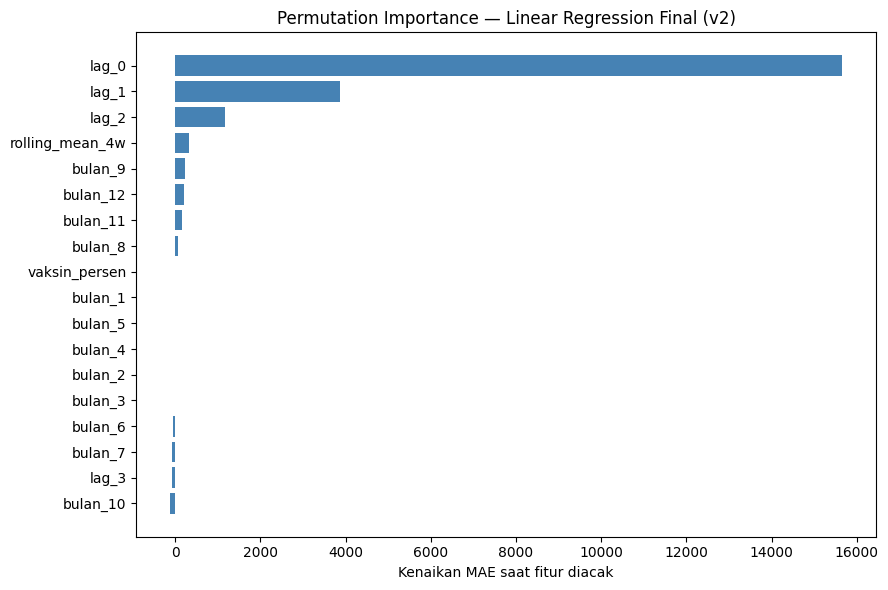

In [5]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat bar chart horizontal dari importance_permutasi.head(8) (8 fitur teratas)
#    pola sama seperti bar chart feature importance Random Forest di Hari 17
# 2. Judul: "Permutation Importance — Linear Regression Final (v2)"
# 3. plt.gca().invert_yaxis() supaya fitur paling penting di atas
# Tulis kode kamu di bawah ini:
importance_urut = importance_permutasi.sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importance_urut.index, importance_urut.values, color="steelblue")
plt.gca().invert_yaxis()
plt.title("Permutation Importance — Linear Regression Final (v2)")
plt.xlabel("Kenaikan MAE saat fitur diacak")
plt.tight_layout()
plt.show()

**Bandingkan urutan ini dengan koefisien mentah dari Hari 24** (`lag_0` paling besar, lalu `lag_1`, `lag_2`). Kalau urutannya mirip, itu memberi keyakinan lebih bahwa fitur-fitur tersebut memang penting. Kalau urutannya beda jauh, itu justru konfirmasi tambahan bahwa koefisien mentah tidak bisa dipercaya.

## Menyimpan Scaler untuk Deployment

Ini bagian penting yang terlewat sejak Hari 23-25: kita punya file CSV hasil scaling, tapi tidak punya **objek scaler**-nya sendiri. Untuk Streamlit nanti, pengguna akan memasukkan angka mentah (belum di-scale) — jadi kita butuh scaler yang identik dengan yang dipakai saat training, disimpan sebagai file terpisah.

In [6]:
# Cell ini sudah lengkap — melatih ulang scaler dengan cara PERSIS sama seperti Hari 23,
# supaya hasilnya identik dengan yang dipakai untuk melatih model_final_v2.

X_train_v2 = pd.read_csv("X_train_v2.csv", index_col=0, parse_dates=True)
kolom_kontinu = ["lag_0", "lag_1", "lag_2", "lag_3", "rolling_mean_4w", "vaksin_persen"]

scaler_final = StandardScaler().fit(X_train_v2[kolom_kontinu])
joblib.dump(scaler_final, "scaler_final.pkl")
joblib.dump(kolom_kontinu, "kolom_kontinu.pkl")  # simpan juga daftar nama kolomnya

print("scaler_final.pkl tersimpan.")
print(f"Kolom yang di-scale: {kolom_kontinu}")

scaler_final.pkl tersimpan.
Kolom yang di-scale: ['lag_0', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_4w', 'vaksin_persen']


## Membangun Fungsi Prediksi (Cikal Bakal Streamlit)

Fungsi ini nanti dipanggil langsung dari aplikasi Streamlit di Hari 27-28 — sekarang kita bangun dan uji dulu di notebook supaya lebih gampang di-debug.

In [7]:
# Cell ini sudah lengkap.

def label_tren(nilai_depan, nilai_sekarang, ambang=0.05):
    perubahan = (nilai_depan - nilai_sekarang) / nilai_sekarang
    if perubahan > ambang:
        return "Naik"
    elif perubahan < -ambang:
        return "Turun"
    else:
        return "Stabil"

def prediksi_minggu_depan(lag_0, lag_1, lag_2, lag_3, rolling_mean_4w, vaksin_persen, bulan):
    """Terima angka MENTAH (belum di-scale), kembalikan (prediksi, label_tren).
    bulan: angka 1-12, bulan dari minggu yang mau diprediksi."""
    kontinu = pd.DataFrame(
        [[lag_0, lag_1, lag_2, lag_3, rolling_mean_4w, vaksin_persen]],
        columns=kolom_kontinu
    )
    kontinu_scaled = scaler_final.transform(kontinu)
    fitur = pd.DataFrame(kontinu_scaled, columns=kolom_kontinu)

    for m in range(1, 13):
        fitur[f"bulan_{m}"] = 1 if m == bulan else 0

    # urutan kolom HARUS sama persis dengan yang dilihat model saat training
    fitur = fitur[model_final_v2.feature_names_in_]

    prediksi = model_final_v2.predict(fitur)[0]
    label = label_tren(prediksi, lag_0)
    return prediksi, label

## Uji Coba Fungsi dengan Beberapa Skenario

In [16]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# Uji fungsi prediksi_minggu_depan() dengan MINIMAL 3 skenario berbeda, tiap skenario
# cetak hasil prediksi + labelnya:
# 1. Skenario "tren naik": pilih angka lag_0 > lag_1 > lag_2 > lag_3 (kasus terus naik
#    beberapa minggu terakhir), vaksin_persen tinggi (misal 70), bulan bebas
# 2. Skenario "tren turun": kebalikannya, lag_0 < lag_1 < lag_2 < lag_3
# 3. Skenario "ambil dari data test asli": ambil satu baris nyata dari X_test_v2.csv
#    (load filenya, pilih index tertentu, masukkan nilai-nilainya ke fungsi), lalu
#    bandingkan hasil fungsi dengan y_test_v2 di tanggal yang sama — seberapa dekat?
# Tulis kode kamu di bawah ini:
skenario1 = prediksi_minggu_depan(lag_0=1200, lag_1=1000, lag_2=900, lag_3=850, 
                               rolling_mean_4w=980, vaksin_persen=70, bulan=6)
print("Skenario naik: ", skenario1)

skenario2 = prediksi_minggu_depan(lag_0=800, lag_1=900, lag_2=1000, lag_3=1100, 
                               rolling_mean_4w=950, vaksin_persen=60, bulan=7)
print("Skenario Turun: ", skenario2)

X_test_v2 = pd.read_csv("X_test_v2.csv", index_col=0, parse_dates=True)
y_test_v2 = pd.read_csv("y_test_v2.csv", index_col=0, parse_dates=True).iloc[:, 0]
baris = X_test_v2.iloc[0]
skenario3 = prediksi_minggu_depan(
    lag_0=baris["lag_0"],
    lag_1=baris["lag_1"],
    lag_2=baris["lag_2"],
    lag_3=baris["lag_3"],
    rolling_mean_4w=baris["rolling_mean_4w"],
    vaksin_persen=baris["vaksin_persen"],
    bulan=baris.name.month
)
print("Skenario data test asli: ", skenario3)
print("Aktual:", y_test_v2.iloc[0])


Skenario naik:  (np.float64(19156.97942628226), 'Naik')
Skenario Turun:  (np.float64(20881.039553680665), 'Naik')
Skenario data test asli:  (np.float64(20702.82337889995), 'Naik')
Aktual: 3688.0


## Dokumentasi Batasan Model untuk Pengguna

Ini teks yang akan ditampilkan langsung di aplikasi Streamlit — tulis dengan bahasa yang bisa dipahami orang tanpa latar belakang statistik (ingat business objective dari Hari 2):

> ⚠️ **Tentang prediksi ini:**
>
> (isi 3-4 kalimat: apa yang model ini BISA lakukan, apa yang TIDAK bisa dijamin, dan kapan pengguna harus lebih hati-hati membaca hasilnya — gunakan temuan dari Hari 22-25: konsisten menang cuma 2 dari 5 periode waktu yang diuji, kurang stabil terutama saat tren berubah cepat)
>
> **Prediksi untuk kombinasi input yang tidak realistis secara historis (misal kasus sangat rendah dikombinasikan dengan cakupan vaksinasi tinggi) bisa tidak akurat, karena model belajar dari pola yang pernah terjadi, bukan menalar sebab-akibat**

> 📊 **Berdasarkan apa prediksi ini dibuat?**
>
> (isi 2-3 kalimat sederhana: fitur apa saja yang paling berpengaruh menurut permutation importance di atas, ditulis dengan bahasa awam bukan istilah teknis)
>
> ...

## Refleksi Hari 26

> 1. Apakah urutan fitur dari permutation importance sama dengan urutan koefisien mentah di Hari 24? → **Sama**
> 2. Dari 3 skenario uji coba — apakah hasil prediksinya masuk akal (skenario naik menghasilkan label "Naik", dst)? → **Kurang, skenario naik menghasilkan label "Naik" tapi skenario turun juga menghasilkan label "Naik"**
> 3. Untuk skenario yang pakai data test asli — seberapa dekat prediksi fungsi dengan angka aktual? Apakah sesuai ekspektasi MAE yang sudah kamu tahu (7.806)? → **selisih prediksi vs aktual untuk baris ini = |20.702,82 - 3.688| = 17.014,82**

---
### Selanjutnya: Hari 27-28 — Bangun Aplikasi Streamlit

Fungsi `prediksi_minggu_depan()`, `model_final_v2.pkl`, dan `scaler_final.pkl` yang sudah diuji hari ini akan langsung dipindah ke file `app.py` Streamlit. Tinggal tambahkan antarmuka (input form) dan tampilan hasil + disclaimer yang sudah kamu tulis di atas.